In [1]:
# essential libraries for numerical operations and data manipulation
import numpy as np
import pandas as pd
# visualization libraries for plotting and charts
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# tools for data preprocessing and model evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# selection of ML models for experimentation
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
df=pd.read_csv("crop recommendation1.csv") # Load the dataset into a DataFrame")
df.head()              

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
# Shuffle the dataset to randomize the order of rows
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,112,9,51,24.891896,89.970825,6.615439,56.955828,watermelon
1,2,33,45,23.716232,92.898672,5.017975,112.965935,pomegranate
2,117,76,47,25.562022,77.382290,6.119216,93.102472,banana
3,31,56,23,31.468462,35.394540,5.661826,174.572400,pigeonpeas
4,109,23,25,25.117110,68.480304,7.007332,194.877348,coffee


In [4]:
dfisnull=df.isnull().sum() # Check for missing values in each column
print(dfisnull)

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [5]:
df = df.drop_duplicates()


In [6]:
# Remove physically impossible values
df = df[df['ph'].between(0, 14)]        # pH scale is 0–14
df = df[df['humidity'].between(0, 100)] # Humidity is 0–100%
df = df[df['rainfall'] >= 0]            # Rainfall can't be negative
df = df[df['N'] >= 0]                   # Nutrient levels can't be negative
df = df[df['P'] >= 0]
df = df[df['K'] >= 0]

after_domain = df.shape

In [7]:
df.info() # Get a concise summary of the DataFrame, including data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
Index: 3198 entries, 0 to 3199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            3198 non-null   int64  
 1   P            3198 non-null   int64  
 2   K            3198 non-null   int64  
 3   temperature  3198 non-null   float64
 4   humidity     3198 non-null   float64
 5   ph           3198 non-null   float64
 6   rainfall     3198 non-null   float64
 7   label        3198 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 224.9+ KB


In [8]:
df.describe() # Generate descriptive statistics for numerical columns in the DataFrame

,N,P,K,temperature,humidity,ph,rainfall
count,3198.000000,3198.000000,3198.000000,3198.000000,3198.000000,3198.000000,3198.000000
mean,50.497186,52.969356,47.581614,25.626018,71.814803,6.459100,103.579737
std,37.095231,33.019245,50.477818,5.170739,21.994691,1.334969,54.986262
min,0.000000,1.000000,0.000000,8.218804,12.387058,0.474757,17.870077
25%,21.000000,27.000000,20.000000,22.676610,60.500027,5.824334,64.692488
50%,37.000000,50.500000,31.000000,25.625911,80.492960,6.415508,95.387240
75%,85.000000,68.000000,48.000000,28.653432,89.757690,7.064928,122.843329
max,140.000000,146.000000,207.000000,48.109568,99.981876,13.922543,299.520155


In [9]:

before_domain=df.head(5) # Get the first 5 rows of the DataFrame
after_domain = df.shape
print("Shape before domain knowledge filtering:", before_domain)
print("Shape after domain knowledge filtering:", after_domain)


Shape before domain knowledge filtering:      N   P   K  temperature   humidity        ph    rainfall        label
0  112   9  51    24.891896  89.970825  6.615439   56.955828   watermelon
1    2  33  45    23.716232  92.898672  5.017975  112.965935  pomegranate
2  117  76  47    25.562022  77.382290  6.119216   93.102472       banana
3   31  56  23    31.468462  35.394540  5.661826  174.572400   pigeonpeas
4  109  23  25    25.117110  68.480304  7.007332  194.877348       coffee
Shape after domain knowledge filtering: (3198, 8)


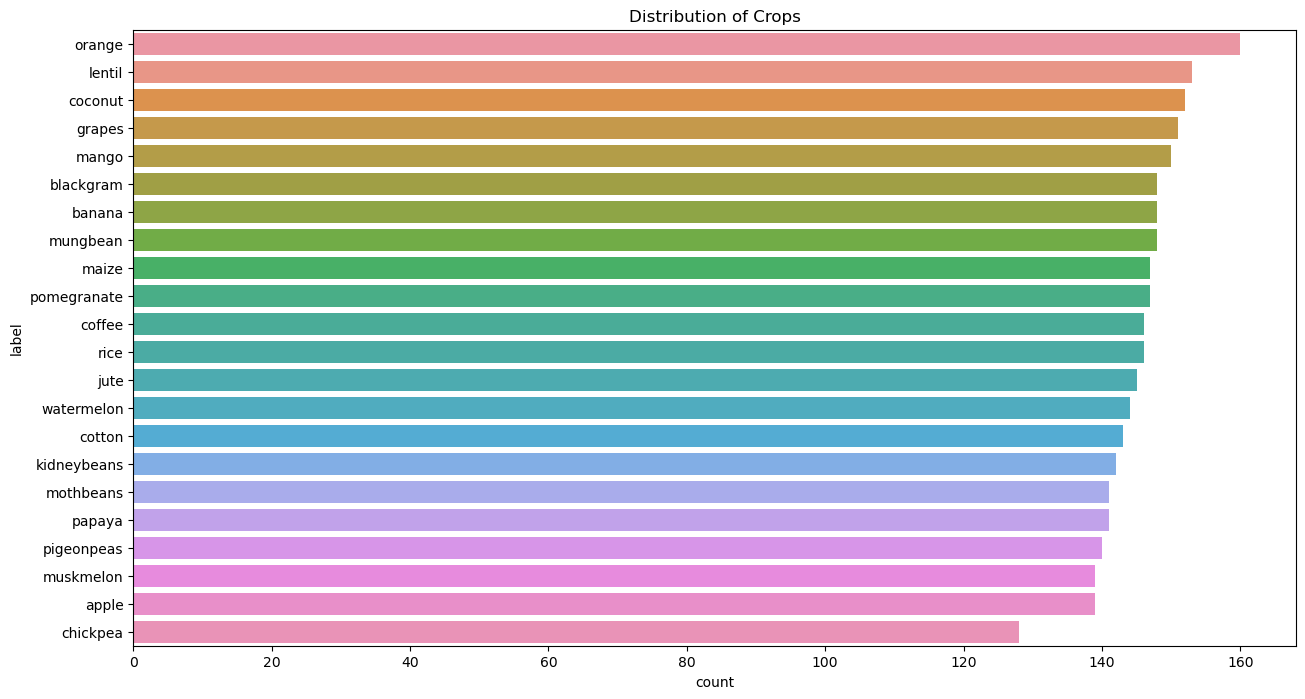

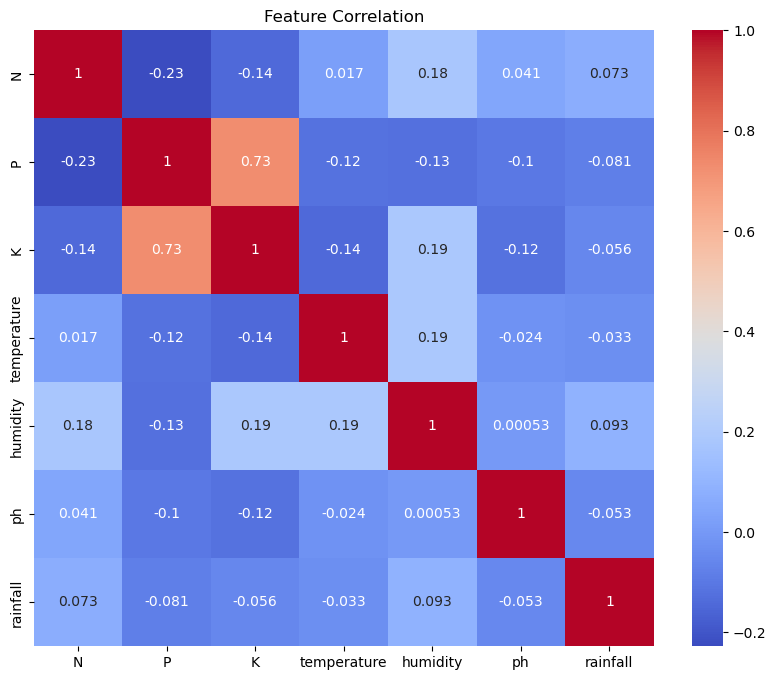

In [10]:
plt.figure(figsize=(15, 8))
sns.countplot(y='label', data=df, order=df['label'].value_counts().index)
plt.title('Distribution of Crops')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [11]:
# List and count the unique crop labels in the target column
unique_crops = df['label'].unique()
print(f"Unique crop labels: {unique_crops}")
print(f"Total unique crops: {len(unique_crops)}")

Unique crop labels: ['watermelon' 'pomegranate' 'banana' 'pigeonpeas' 'coffee' 'mothbeans'
 'maize' 'coconut' 'orange' 'mango' 'jute' 'apple' 'rice' 'kidneybeans'
 'blackgram' 'lentil' 'muskmelon' 'grapes' 'mungbean' 'chickpea' 'papaya'
 'cotton']
Total unique crops: 22


In [12]:
# Compile key dataset statistics into a summary dictionary
summary = {
    "Shape": df.shape,
    "Missing Values": df.isnull().sum().sum(),
    "Duplicates": df.duplicated().sum(),
    "Unique Labels": df['label'].nunique(),
    "Labels": list(df['label'].unique())
}
summary

{'Shape': (3198, 8),
 'Missing Values': 0,
 'Duplicates': 0,
 'Unique Labels': 22,
 'Labels': ['watermelon',
  'pomegranate',
  'banana',
  'pigeonpeas',
  'coffee',
  'mothbeans',
  'maize',
  'coconut',
  'orange',
  'mango',
  'jute',
  'apple',
  'rice',
  'kidneybeans',
  'blackgram',
  'lentil',
  'muskmelon',
  'grapes',
  'mungbean',
  'chickpea',
  'papaya',
  'cotton']}

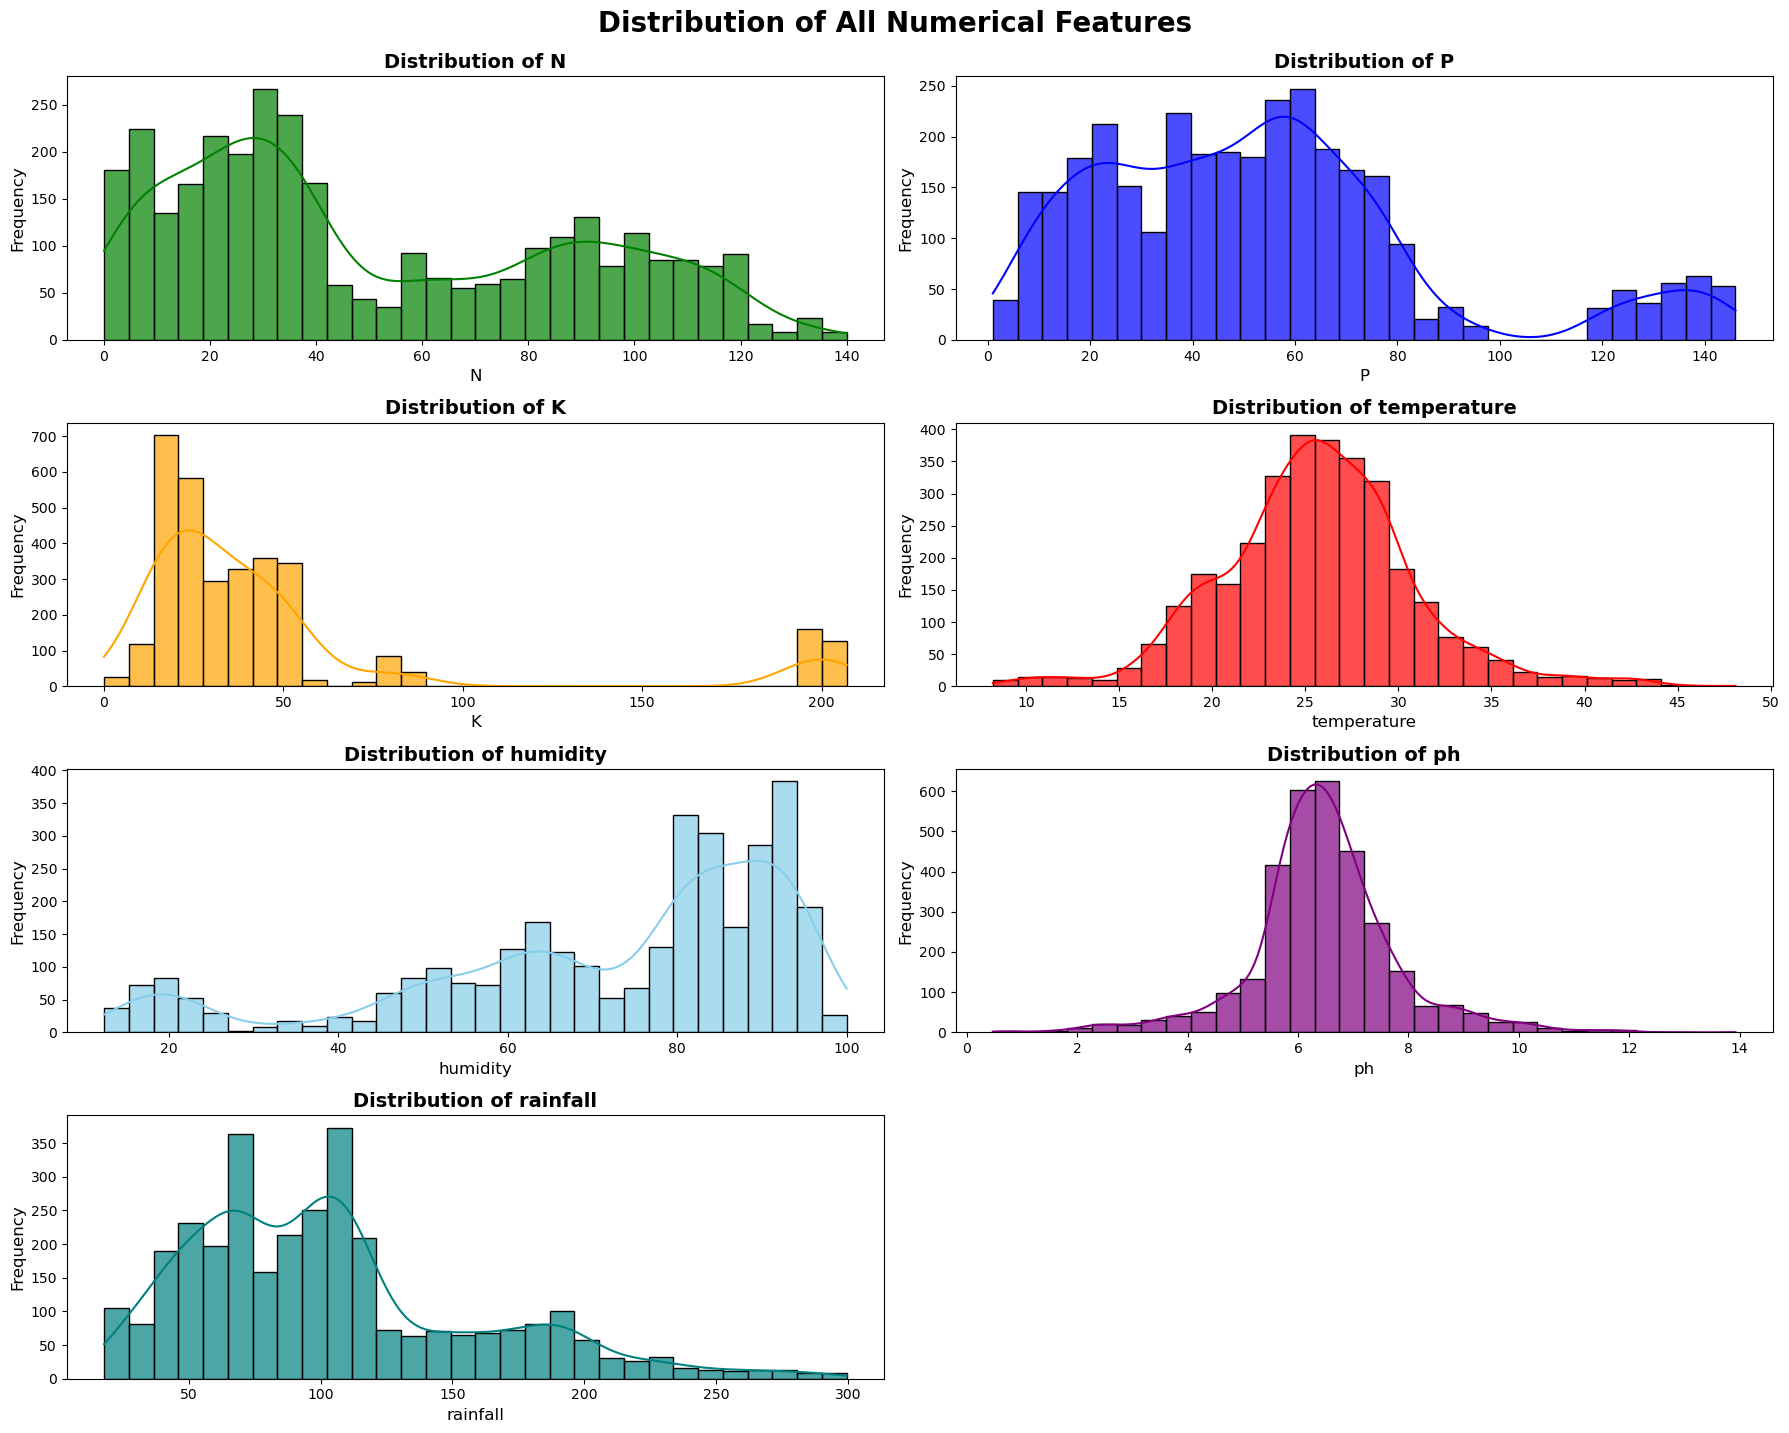

In [13]:
# Plot the distributions of all numerical features using subplots

# List of numerical features
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
colors = ['green', 'blue', 'orange', 'red', 'skyblue', 'purple', 'teal']

# Create subplots
plt.figure(figsize=(18, 14))

for i, feature in enumerate(features):
    plt.subplot(4, 2, i+1)          # 4 rows, 2 columns
    sns.histplot(df[feature], 
                 kde=True,           # Show density curve
                 bins=30, 
                 color=colors[i],
                 alpha=0.7)
    
    plt.title(f'Distribution of {feature}', fontsize=14, fontweight='bold')
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

# Remove the empty 8th subplot
plt.subplot(4, 2, 8).remove()

plt.tight_layout()
plt.suptitle('Distribution of All Numerical Features', 
             fontsize=20, fontweight='bold', y=1.02)
plt.show()

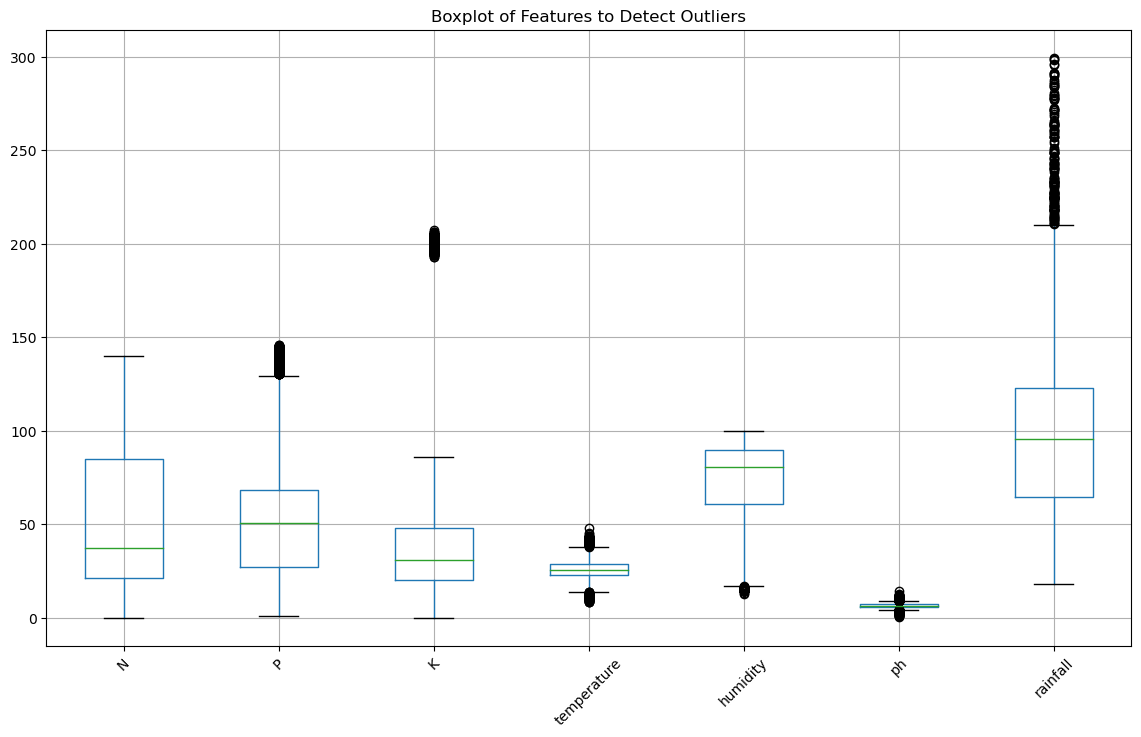

In [14]:
# Use boxplots to detect outliers for each numeric feature
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
plt.figure(figsize=(14,8))
df[features].boxplot(rot=45)
plt.title('Boxplot of Features to Detect Outliers')
plt.show()

c:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


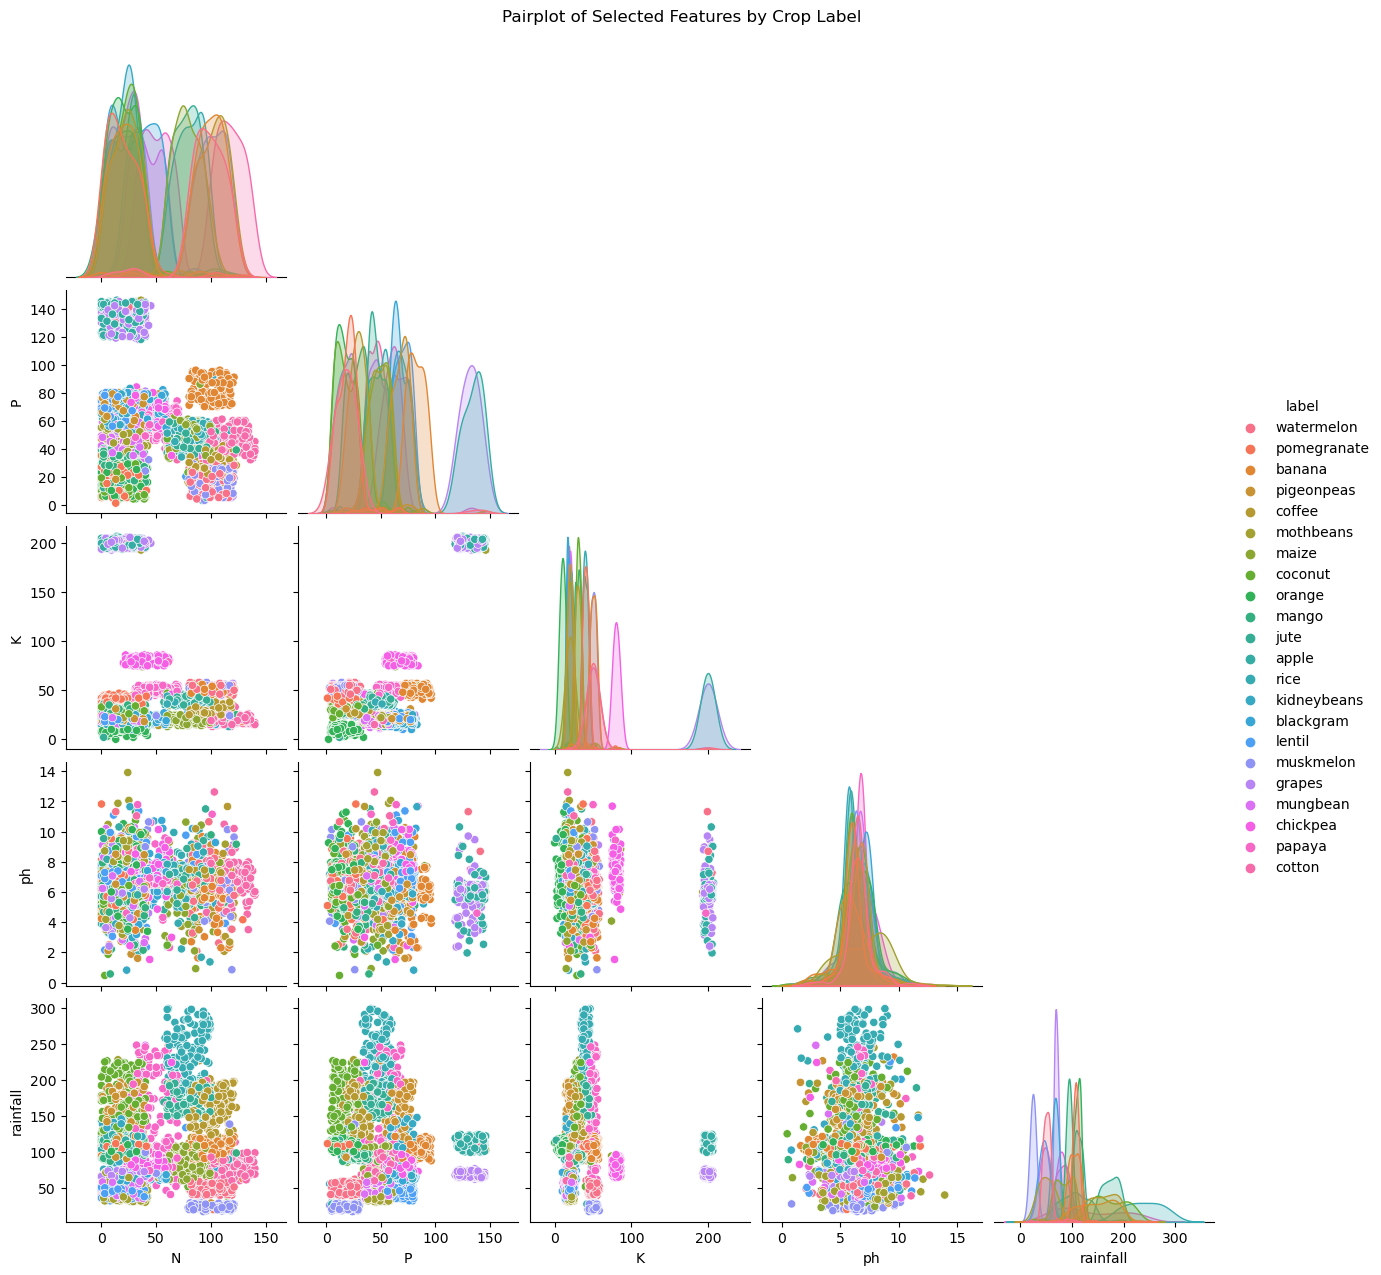

In [15]:
# Create a pairplot of key features with hue based on crop labels
sns.pairplot(df[['N', 'P', 'K', 'ph', 'rainfall', 'label']], hue='label', diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Selected Features by Crop Label', y=1.02)
plt.show()


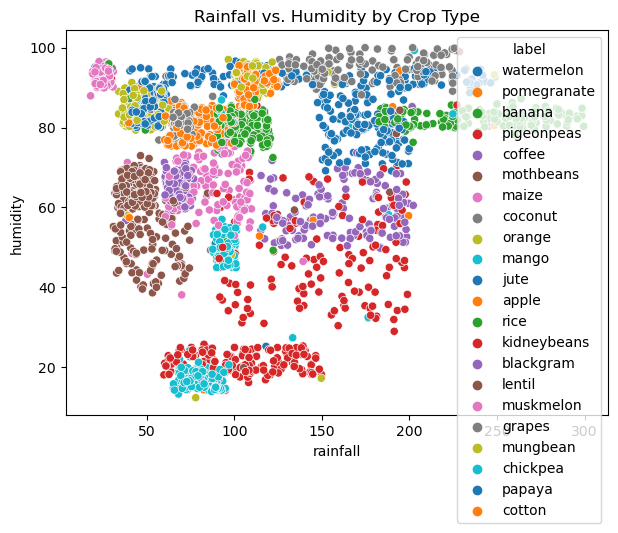

In [16]:
# Scatter plot between rainfall and humidity
plt.figure(figsize=(7,5))
sns.scatterplot(x='rainfall', y='humidity', hue='label', data=df, palette='tab10')
plt.title('Rainfall vs. Humidity by Crop Type')
plt.show()

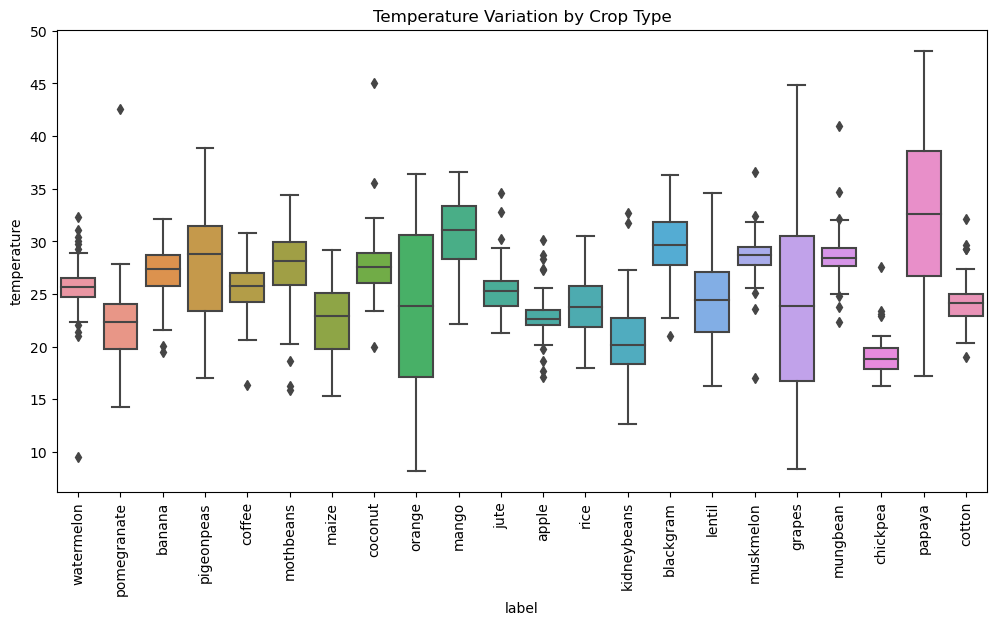

In [17]:
# Boxplot of temperature values for different crop types
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='temperature', data=df)
plt.xticks(rotation=90)
plt.title('Temperature Variation by Crop Type')
plt.show()

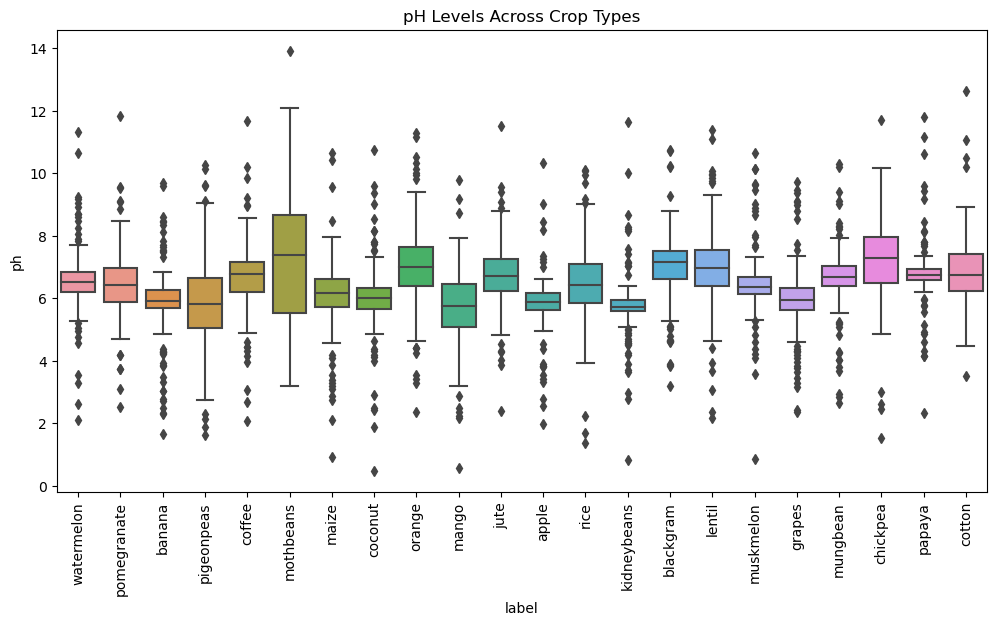

In [18]:
# Boxplot of pH values across different crops
plt.figure(figsize=(12,6))
sns.boxplot(x='label', y='ph', data=df)
plt.xticks(rotation=90)
plt.title('pH Levels Across Crop Types')
plt.show()

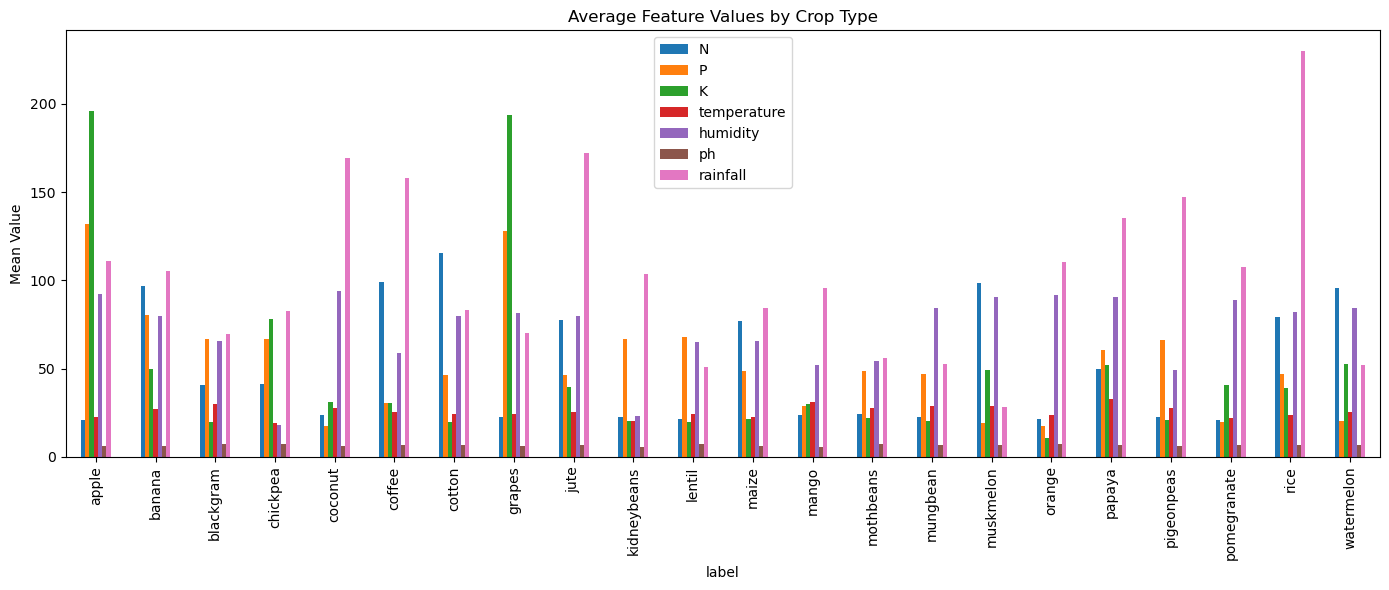

In [19]:
# Group by crop label and plot the mean values of features
grouped = df.groupby('label').mean().reset_index()
grouped.set_index('label').plot(kind='bar', figsize=(14,6))
plt.title('Average Feature Values by Crop Type')
plt.ylabel('Mean Value')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [20]:
# Print the min and max values for each numerical feature
for col in df.select_dtypes(include=np.number).columns:
    print(f"{col}: Min = {df[col].min()}, Max = {df[col].max()}")

N: Min = 0, Max = 140
P: Min = 1, Max = 146
K: Min = 0, Max = 207
temperature: Min = 8.218804057, Max = 48.10956767
humidity: Min = 12.38705849, Max = 99.98187601
ph: Min = 0.474757365, Max = 13.92254286
rainfall: Min = 17.87007654, Max = 299.5201554


In [21]:
# Define feature set and target variable
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

In [22]:
# Encode crop labels to numerical format
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [23]:
# Normalize features for better performance in distance-based models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 2398
Testing samples: 800


In [25]:
# Use cosine similarity for recommending crops based on features
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(X_scaled)

In [26]:
# Return top 5 crops similar to a given sample based on cosine similarity
def recommend_similar_crops(index, top_n=5):
    sim_scores = list(enumerate(similarity_matrix[index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    crop_indices = [i[0] for i in sim_scores]
    return df['label'].iloc[crop_indices].values

In [27]:
# Test the content-based crop recommender
sample_index = 0
print(f"Input Crop: {df['label'][sample_index]}")
print("Recommended Similar Crops:", recommend_similar_crops(sample_index))

Input Crop: watermelon
Recommended Similar Crops: ['watermelon' 'watermelon' 'watermelon' 'watermelon' 'watermelon']


In [28]:
# Build and train a classifier (Random Forest used here)
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [29]:
# Predict crops and convert encoded output back to original label
y_pred = rf_model.predict(X_test)
decoded_preds = le.inverse_transform(y_pred)

In [30]:
# Combine similarity and ML predictions
def hybrid_recommender(input_features):
    input_scaled = scaler.transform([input_features])
    predicted_crop = le.inverse_transform(rf_model.predict(input_scaled))[0]
    input_index = cosine_similarity(input_scaled, X_scaled).argmax()
    similar_crops = recommend_similar_crops(input_index)
    return predicted_crop, similar_crops

In [31]:
# Test hybrid recommender with a sample input
sample_input = X.iloc[10].values
predicted_crop, similar_crops = hybrid_recommender(sample_input)
print(f"Predicted Crop: {predicted_crop}")
print(f"Recommended Alternatives: {similar_crops}")

Predicted Crop: orange
Recommended Alternatives: ['orange' 'orange' 'orange' 'orange' 'orange']


c:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


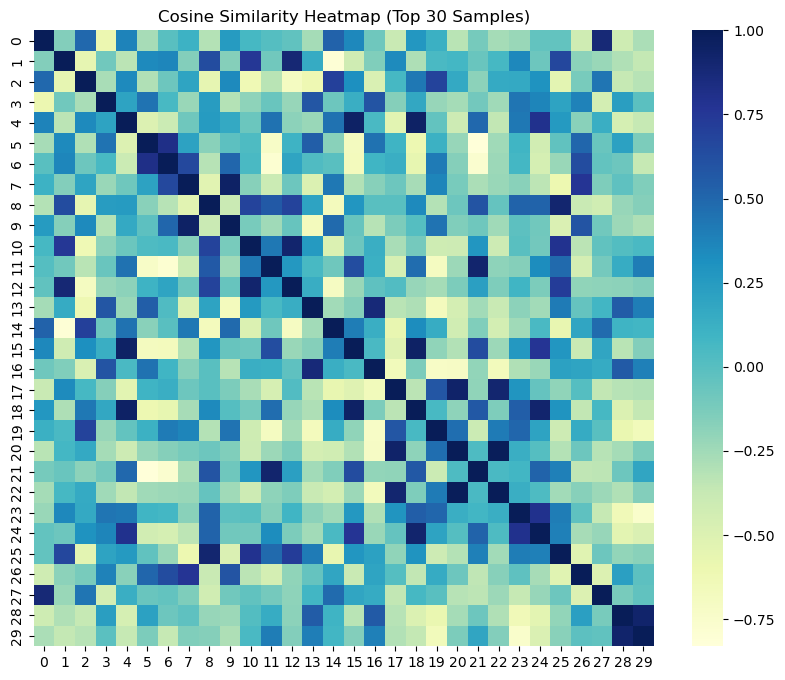

In [32]:
# Plot similarity heatmap (sample for first 30 entries)
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix[:30, :30], cmap='YlGnBu')
plt.title("Cosine Similarity Heatmap (Top 30 Samples)")
plt.show()


In [33]:
# Print ML model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Classifier Accuracy: {accuracy:.2f}")

Random Forest Classifier Accuracy: 0.94


In [34]:
from sklearn.metrics import classification_report

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    results.append([name, accuracy])
    label_encoder = le
    

    
    print(f"\n{'='*60}")
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

# Summary Table
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])
print("\n📊 Model Comparison:")
print(results_df.sort_values(by='Accuracy', ascending=False))
print("le.classes_:", le.classes_)


Random Forest Accuracy: 0.9437
              precision    recall  f1-score   support

       apple       0.97      0.97      0.97        35
      banana       0.95      0.97      0.96        37
   blackgram       0.97      1.00      0.99        37
    chickpea       0.94      0.94      0.94        32
     coconut       0.95      0.97      0.96        38
      coffee       0.92      0.95      0.93        37
      cotton       0.85      0.92      0.88        36
      grapes       0.97      0.95      0.96        38
        jute       0.92      0.97      0.95        36
 kidneybeans       0.97      0.94      0.96        35
      lentil       0.93      1.00      0.96        38
       maize       1.00      0.84      0.91        37
       mango       0.92      0.95      0.94        38
   mothbeans       0.91      0.91      0.91        35
    mungbean       0.89      0.89      0.89        37
   muskmelon       0.95      1.00      0.97        35
      orange       1.00      0.97      0.99      

In [35]:
from sklearn.model_selection import GridSearchCV

# Best model so far is Random Forest
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Final Tuned Model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("\n🎯 Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Cross-Validation Score: 0.9470415796798888

🎯 Tuned Random Forest Accuracy: 0.945


In [36]:
# Compare true vs predicted crop types (first 20)
print("Actual:", le.inverse_transform(y_test[:20]))
print("Predicted:", decoded_preds[:20])

Actual: ['papaya' 'rice' 'watermelon' 'banana' 'coffee' 'apple' 'cotton' 'cotton'
 'maize' 'mothbeans' 'grapes' 'banana' 'coffee' 'banana' 'chickpea'
 'pomegranate' 'pomegranate' 'orange' 'muskmelon' 'maize']
Predicted: ['papaya' 'rice' 'watermelon' 'banana' 'coffee' 'apple' 'cotton' 'cotton'
 'banana' 'mothbeans' 'grapes' 'banana' 'coffee' 'banana' 'chickpea'
 'pomegranate' 'pomegranate' 'orange' 'muskmelon' 'maize']


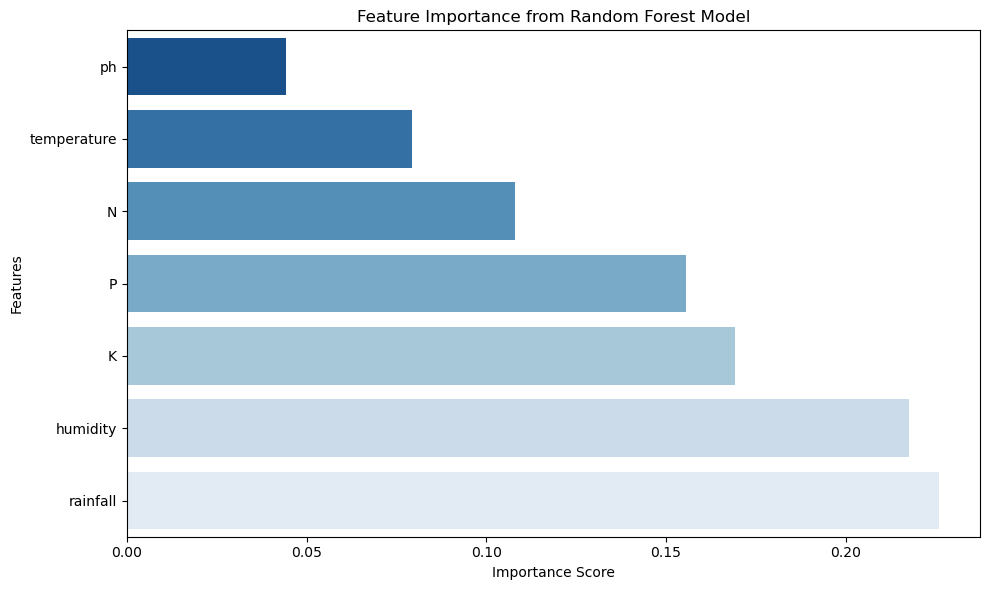

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you already have the trained Random Forest model
# and that X_train or X contains the feature names

# Get feature importances
feature_importances = rf_model.feature_importances_

# Create a pandas series for visualization
features = X.columns  # replace X with your actual DataFrame used for training
importance_series = pd.Series(feature_importances, index=features)

# Sort the features by importance
importance_series_sorted = importance_series.sort_values(ascending=True)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=importance_series_sorted, y=importance_series_sorted.index, palette='Blues_r')
plt.title("Feature Importance from Random Forest Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [38]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Average accuracy:", scores.mean())

Cross-validation scores: [0.9421875  0.9421875  0.9546875  0.93583725 0.95305164]
Average accuracy: 0.9455902777777776


In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Train and evaluate Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# Evaluation metrics
print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_log, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_log, average='weighted'))

# Crop recommendation test
print("Actual:", le.inverse_transform(y_test[:20]))
print("Predicted:", le.inverse_transform(y_pred_log[:20]))

Logistic Regression Metrics:
Accuracy: 0.90875
Precision: 0.9125236429443772
Recall: 0.90875
F1 Score: 0.9082826517932553
Actual: ['papaya' 'rice' 'watermelon' 'banana' 'coffee' 'apple' 'cotton' 'cotton'
 'maize' 'mothbeans' 'grapes' 'banana' 'coffee' 'banana' 'chickpea'
 'pomegranate' 'pomegranate' 'orange' 'muskmelon' 'maize']
Predicted: ['papaya' 'rice' 'watermelon' 'banana' 'coffee' 'apple' 'cotton' 'cotton'
 'banana' 'mothbeans' 'grapes' 'banana' 'coffee' 'banana' 'chickpea'
 'pomegranate' 'pomegranate' 'orange' 'muskmelon' 'maize']


In [40]:
# Train and evaluate KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

# Evaluation metrics
print("KNN Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_knn, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_knn, average='weighted'))

# Crop recommendation test
print("Actual:", le.inverse_transform(y_test[:20]))
print("Predicted:", le.inverse_transform(y_pred_knn[:20]))

KNN Metrics:
Accuracy: 0.88875
Precision: 0.8934202298009974
Recall: 0.88875
F1 Score: 0.8877453424746693
Actual: ['papaya' 'rice' 'watermelon' 'banana' 'coffee' 'apple' 'cotton' 'cotton'
 'maize' 'mothbeans' 'grapes' 'banana' 'coffee' 'banana' 'chickpea'
 'pomegranate' 'pomegranate' 'orange' 'muskmelon' 'maize']
Predicted: ['papaya' 'rice' 'watermelon' 'banana' 'coffee' 'apple' 'cotton' 'cotton'
 'banana' 'mothbeans' 'grapes' 'banana' 'coffee' 'banana' 'chickpea'
 'pomegranate' 'pomegranate' 'orange' 'muskmelon' 'cotton']


In [41]:
from sklearn.tree import DecisionTreeClassifier

# Train and evaluate Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Evaluation metrics
print("Decision Tree Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_dt, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_dt, average='weighted'))

# Crop recommendation test
print("Actual:", le.inverse_transform(y_test[:20]))
print("Predicted:", le.inverse_transform(y_pred_dt[:20]))

Decision Tree Metrics:
Accuracy: 0.89
Precision: 0.8928597960282161
Recall: 0.89
F1 Score: 0.8898343149788228
Actual: ['papaya' 'rice' 'watermelon' 'banana' 'coffee' 'apple' 'cotton' 'cotton'
 'maize' 'mothbeans' 'grapes' 'banana' 'coffee' 'banana' 'chickpea'
 'pomegranate' 'pomegranate' 'orange' 'muskmelon' 'maize']
Predicted: ['papaya' 'rice' 'watermelon' 'banana' 'coffee' 'apple' 'cotton' 'cotton'
 'banana' 'mothbeans' 'grapes' 'banana' 'coffee' 'banana' 'chickpea'
 'pomegranate' 'pomegranate' 'orange' 'muskmelon' 'maize']


In [42]:
# Import necessary libraries
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Optionally: Encode labels if not already done
# le = LabelEncoder()
# y_train = le.fit_transform(y_train)
# y_test = le.transform(y_test)

# Option 1: Gradient Boosting (optimized for speed)
gb_model = GradientBoostingClassifier(
    n_estimators=50,      # Reduce number of boosting rounds
    max_depth=3,          # Limit tree depth
    learning_rate=0.1,    # Standard learning rate
    subsample=0.8,        # Use a subset of data for each tree
    random_state=42
)

try:
    gb_model.fit(X_train, y_train)
    y_pred_gb = gb_model.predict(X_test)

    # Evaluation metrics
    print("Gradient Boosting Metrics:")
    print("Accuracy:", accuracy_score(y_test, y_pred_gb))
    print("Precision:", precision_score(y_test, y_pred_gb, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred_gb, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred_gb, average='weighted'))

    # Crop recommendation test output
    print("\nCrop Recommendation (First 20 Samples):")
    print("Actual:   ", le.inverse_transform(y_test[:20]))
    print("Predicted:", le.inverse_transform(y_pred_gb[:20]))

except KeyboardInterrupt:
    print("Training was manually interrupted.")

# Option 2: Faster training using HistGradientBoostingClassifier (if supported)
# Uncomment to use instead:
# hgb_model = HistGradientBoostingClassifier(random_state=42)
# hgb_model.fit(X_train, y_train)
# y_pred_hgb = hgb_model.predict(X_test)

Gradient Boosting Metrics:
Accuracy: 0.9275
Precision: 0.9291348728577182
Recall: 0.9275
F1 Score: 0.9275412488233107

Crop Recommendation (First 20 Samples):
Actual:    ['papaya' 'rice' 'watermelon' 'banana' 'coffee' 'apple' 'cotton' 'cotton'
 'maize' 'mothbeans' 'grapes' 'banana' 'coffee' 'banana' 'chickpea'
 'pomegranate' 'pomegranate' 'orange' 'muskmelon' 'maize']
Predicted: ['papaya' 'rice' 'watermelon' 'banana' 'coffee' 'apple' 'cotton' 'cotton'
 'banana' 'mothbeans' 'grapes' 'banana' 'coffee' 'banana' 'chickpea'
 'pomegranate' 'pomegranate' 'orange' 'muskmelon' 'cotton']


In [43]:
# Train and evaluate random forest (already done, but included here for completeness)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluation metrics
print("Random Forest Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))

# Crop recommendation test
print("Actual:", le.inverse_transform(y_test[:20]))
print("Predicted:", le.inverse_transform(y_pred_rf[:20]))

Random Forest Metrics:
Accuracy: 0.945
Precision: 0.9461416151776183
Recall: 0.945
F1 Score: 0.9448964718217251
Actual: ['papaya' 'rice' 'watermelon' 'banana' 'coffee' 'apple' 'cotton' 'cotton'
 'maize' 'mothbeans' 'grapes' 'banana' 'coffee' 'banana' 'chickpea'
 'pomegranate' 'pomegranate' 'orange' 'muskmelon' 'maize']
Predicted: ['papaya' 'rice' 'watermelon' 'banana' 'coffee' 'apple' 'cotton' 'cotton'
 'banana' 'mothbeans' 'grapes' 'banana' 'coffee' 'banana' 'chickpea'
 'pomegranate' 'pomegranate' 'orange' 'muskmelon' 'maize']


In [44]:
# Compare all models on accuracy, precision, recall, F1
models = {
    'Random Forest': (rf_model, y_pred_rf),
    'Logistic Regression': (log_model, y_pred_log),
    'KNN': (knn_model, y_pred_knn),
    'Decision Tree': (dt_model, y_pred_dt),
    'Gradient Boosting': (gb_model, y_pred_gb)
}

print("{:<20} {:<10} {:<10} {:<10} {:<10}".format('Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'))
for name, (model, pred) in models.items():
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average='weighted')
    rec = recall_score(y_test, pred, average='weighted')
    f1 = f1_score(y_test, pred, average='weighted')
    print(f"{name:<20} {acc:<10.4f} {prec:<10.4f} {rec:<10.4f} {f1:<10.4f}")

Model                Accuracy   Precision  Recall     F1 Score  
Random Forest        0.9450     0.9461     0.9450     0.9449    
Logistic Regression  0.9087     0.9125     0.9087     0.9083    
KNN                  0.8888     0.8934     0.8888     0.8877    
Decision Tree        0.8900     0.8929     0.8900     0.8898    
Gradient Boosting    0.9275     0.9291     0.9275     0.9275    


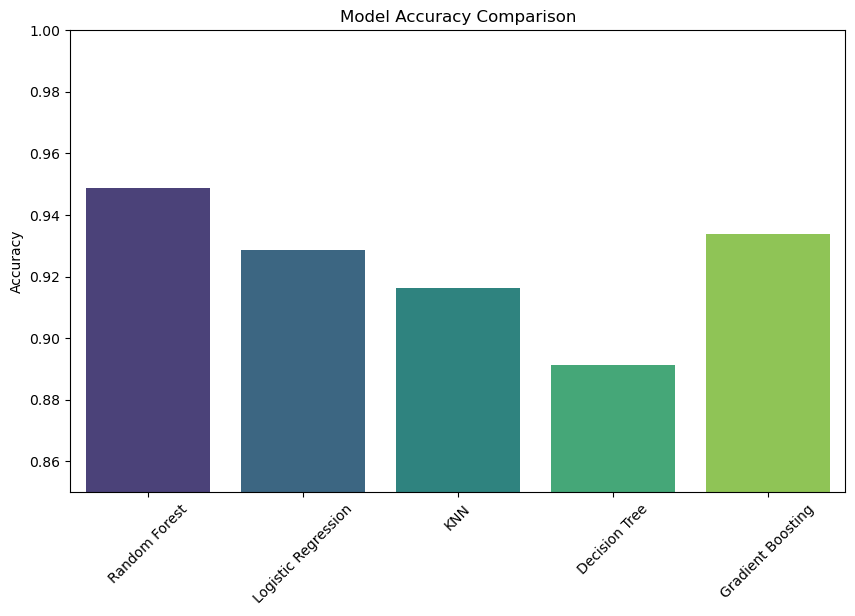

In [45]:
# Plot Accuracy of all models
model_names = ['Random Forest', 'Logistic Regression', 'KNN', 'Decision Tree', 'Gradient Boosting']
accuracies = [0.9487, 0.9287, 0.9163, 0.8912, 0.9337]

plt.figure(figsize=(10,6))
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=45)
plt.show()

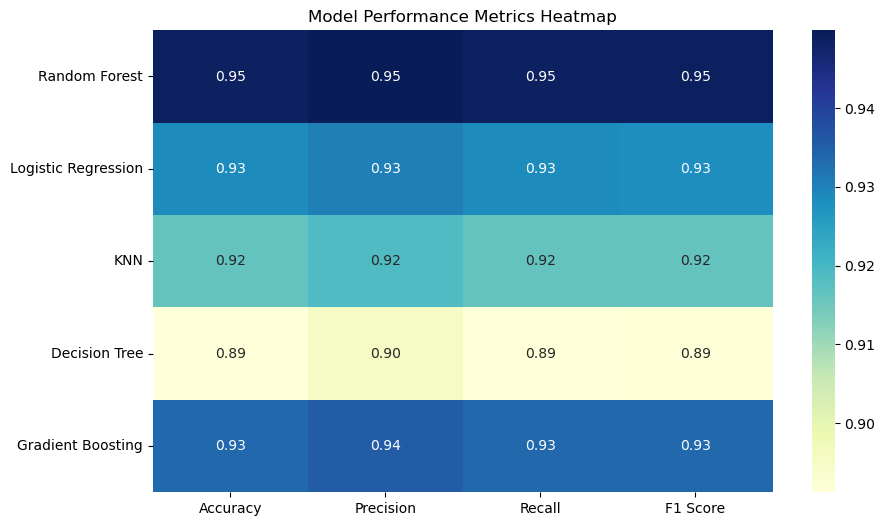

In [46]:
# Combined heatmap for all metrics
precisions = [0.9499, 0.9303, 0.9189, 0.8950, 0.9355]
recalls = [0.9487, 0.9287, 0.9163, 0.8912, 0.9337]
f1_scores = [0.9488, 0.9283, 0.9162, 0.8917, 0.9338]
metrics_df = pd.DataFrame({
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1 Score': f1_scores
}, index=model_names)

plt.figure(figsize=(10,6))
sns.heatmap(metrics_df, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Model Performance Metrics Heatmap')
plt.show()

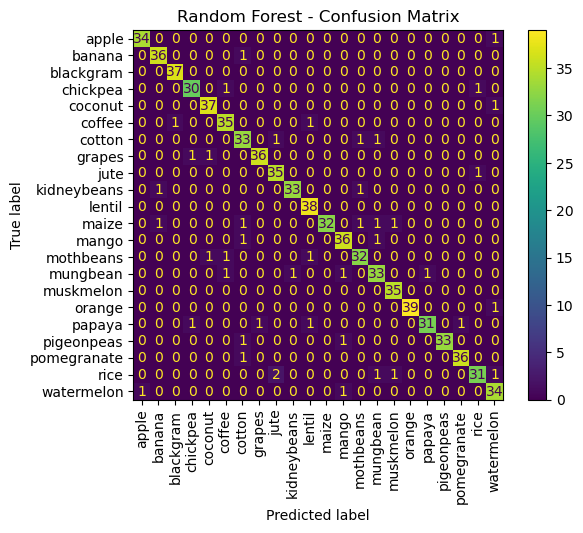

In [47]:
# Confusion matrix for best model (Random Forest)
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, display_labels=le.classes_, xticks_rotation=90)
plt.title("Random Forest - Confusion Matrix")
plt.show()


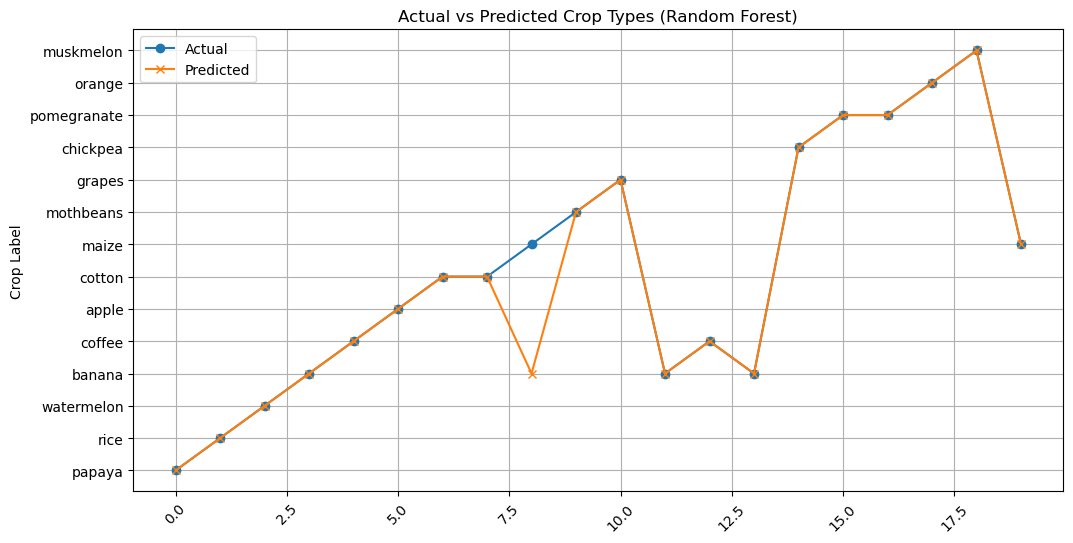

In [48]:
# Plot actual vs predicted for first 20 samples
actual_labels = le.inverse_transform(y_test[:20])
predicted_labels = le.inverse_transform(y_pred[:20])

plt.figure(figsize=(12,6))
plt.plot(actual_labels, label='Actual', marker='o')
plt.plot(predicted_labels, label='Predicted', marker='x')
plt.xticks(rotation=45)
plt.title("Actual vs Predicted Crop Types (Random Forest)")
plt.ylabel("Crop Label")
plt.legend()
plt.grid(True)
plt.show()

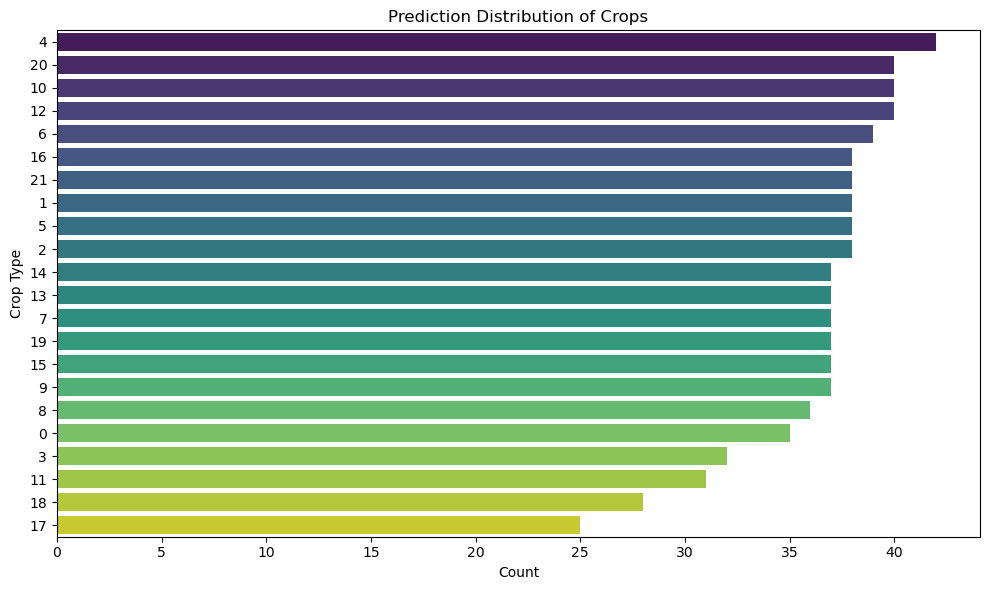

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming y_pred contains the model's predicted crop labels
# and y_test is your true labels

# Convert predictions to a Pandas Series for plotting
pred_series = pd.Series(y_pred, name="Predicted Crop")

# Create a count plot
plt.figure(figsize=(10, 6))
sns.countplot(data=pred_series.to_frame(), y="Predicted Crop", order=pred_series.value_counts().index, palette="viridis")
plt.title("Prediction Distribution of Crops")
plt.xlabel("Count")
plt.ylabel("Crop Type")
plt.tight_layout()
plt.show()

In [50]:
# Function to recommend crop using Random Forest
def recommend_crop(input_features):
    input_array = np.array(input_features).reshape(1, -1)
    prediction = rf_model.predict(input_array)
    predicted_crop = le.inverse_transform(prediction)[0]
    return predicted_crop

In [51]:
# Example test for crop recommendation
sample_input = [25, 40, 60, 20.5, 60.0, 5.5, 150.0]  # N, P, K, temp, humidity, pH, rainfall
recommended_crop = recommend_crop(sample_input)
print("Recommended Crop:", recommended_crop)

Recommended Crop: apple


Saving selected model

In [52]:
# Save the trained model into a file using joblib
import joblib
joblib.dump(rf_model, 'crop_recommendation_rf_model.joblib')

['crop_recommendation_rf_model.joblib']

In [53]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("crop recommendation1.csv")

# Feature selection
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_scaled, y_encoded)

# Save the models and trained scaler and label encoder for future use
joblib.dump(rf_model, 'crop_recommendation_rf_model.joblib') 
joblib.dump(scaler, 'crop_recommendation_scaler.joblib')
joblib.dump(le, 'crop_recommendation_label_encoder.joblib')

# Save X_scaled for hybrid recommendation
joblib.dump(X_scaled, 'crop_recommendation_X_scaled.joblib')

['crop_recommendation_X_scaled.joblib']

In [54]:
# Load saved models and data
import joblib
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

rf_model_loaded = joblib.load('crop_recommendation_rf_model.joblib')
scaler_loaded = joblib.load('crop_recommendation_scaler.joblib')
le_loaded = joblib.load('crop_recommendation_label_encoder.joblib')
X_scaled_loaded = joblib.load('crop_recommendation_X_scaled.joblib')

# Recommend similar crops based on cosine similarity
def recommend_similar_crops(input_index, top_n=5):
    similarity_scores = cosine_similarity(X_scaled_loaded[input_index].reshape(1, -1), X_scaled_loaded)[0]
    similar_indices = np.argsort(similarity_scores)[::-1][1:top_n+1]
    similar_crops = y.iloc[similar_indices]
    return similar_crops

# Hybrid recommendation function combining ML prediction and similarity-based recommendation
def hybrid_recommender(input_features):
    input_scaled = scaler_loaded.transform([input_features])
    predicted_crop = le_loaded.inverse_transform(rf_model_loaded.predict(input_scaled))[0]
    input_index = cosine_similarity(input_scaled, X_scaled_loaded).argmax()
    similar_crops = recommend_similar_crops(input_index)
    similar_crops = list(dict.fromkeys(similar_crops))  # Remove duplicates while preserving order
    similar_crops = [crop for crop in similar_crops if crop != predicted_crop]  # Exclude the predicted crop
    return predicted_crop, similar_crops

# Example test
sample_input = X.iloc[15].values  # Sample input from the dataset
predicted_crop,  similar_crops = hybrid_recommender(sample_input)
print(f"Predicted Crop: {predicted_crop}")
print(f"Recommended Similar Crops: {similar_crops}")

Predicted Crop: rice
Recommended Similar Crops: ['jute']


c:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
